# 04 Logistisk regresjon og klassifiseringsmetrikker
*Data Mining & Analytics – Samling 2, dag 2 (klassifisering)*

In [ ]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"    

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

## Sigmoid og logistisk regresjon

Lineær regresjon kan gi verdier utenfor [0, 1]. Logistisk regresjon «skviser» den lineære kombinasjonen gjennom sigmoid-aktivering



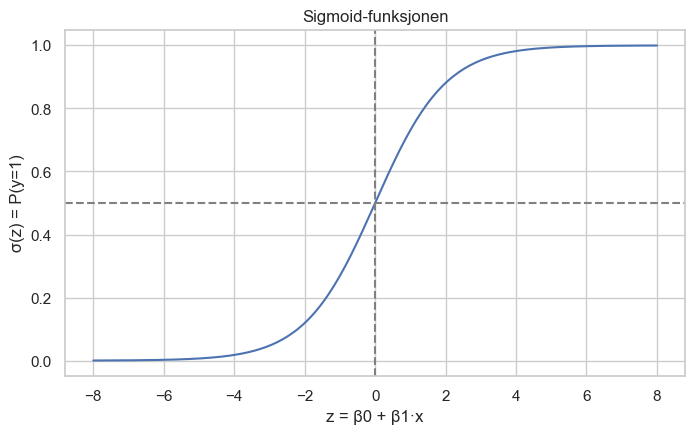

In [3]:
z = np.linspace(-8, 8, 200)
plt.plot(z, 1 / (1 + np.exp(-z)))
plt.axhline(0.5, color="gray", ls="--")
plt.axvline(0, color="gray", ls="--")
plt.xlabel("z = β0 + β1·x")
plt.ylabel("σ(z) = P(y=1)")
plt.title("Sigmoid-funksjonen")
plt.show()

Eksempel: studietimer (Python) vs. bestått eksamen (0/1), syntetiske data.

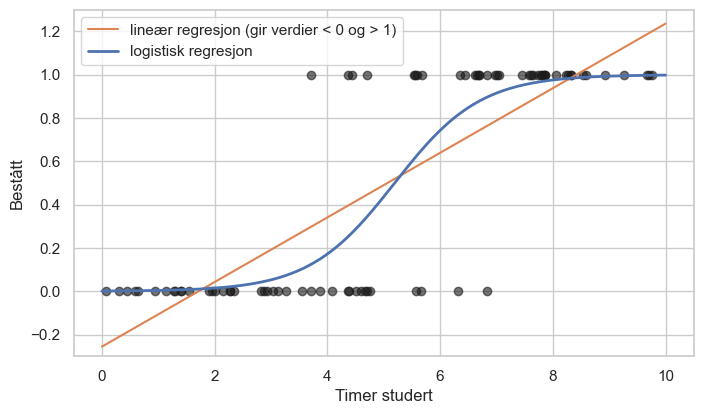

Odds ratio per ekstra time: 3.73  (odds for å bestå ganges med dette for hver time)


In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
timer = rng.uniform(0, 10, 80)
bestatt = (rng.random(80) < 1 / (1 + np.exp(-(timer - 5) * 1.2))).astype(int)

xs = np.linspace(0, 10, 200).reshape(-1, 1)
lin = LinearRegression().fit(timer.reshape(-1, 1), bestatt)
log = LogisticRegression().fit(timer.reshape(-1, 1), bestatt)
plt.scatter(timer, bestatt, alpha=0.6, color="k")
plt.plot(xs, lin.predict(xs), "C1", label="lineær regresjon (gir verdier < 0 og > 1)")
plt.plot(xs, log.predict_proba(xs)[:, 1], "C0", lw=2, label="logistisk regresjon")
plt.ylim(-0.3, 1.3)
plt.xlabel("Timer studert")
plt.ylabel("Bestått")
plt.legend()
plt.show()

## Brystkreftdata

569 svulster, 30 variabler beregnet fra bilder av cellekjerner. ondartet = 1 (positiv klasse).

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kreft = load_breast_cancer(as_frame=True)
X = kreft.data
y = 1 - kreft.target                     # sklearn: 0 = ondartet -> snu slik at 1 = ondartet
print(y.value_counts().rename({0: "godartet", 1: "ondartet"}))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
model.fit(X_train, y_train)
p_test = model.predict_proba(X_test)[:, 1]          # sannsynlighet for ondartet


target
godartet    357
ondartet    212
Name: count, dtype: int64


## Confusion matrix og metrikker

| | Predikert 0 | Predikert 1 |
|---|---|---|
| **Faktisk 0** | TN | FP |
| **Faktisk 1** | FN | TP |



In [ ]:
from sklearn.metrics import confusion_matrix

def klassifiserings_metrikker(y_sann, y_pred):
    """Metrikker for binær klassifisering (positiv klasse = 1)."""
    tn, fp, fn, tp = confusion_matrix(y_sann, y_pred, labels=[0, 1]).ravel()
    return {"nøyaktighet": (tp + tn) / (tp + tn + fp + fn),
            "sensitivitet": tp / (tp + fn) if tp + fn else np.nan,
            "spesifisitet": tn / (tn + fp) if tn + fp else np.nan,
            "presisjon": tp / (tp + fp) if tp + fp else np.nan,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan}

{'nøyaktighet': np.float64(0.965), 'sensitivitet': np.float64(0.925), 'spesifisitet': np.float64(0.989), 'presisjon': np.float64(0.98), 'F1': np.float64(0.951)}


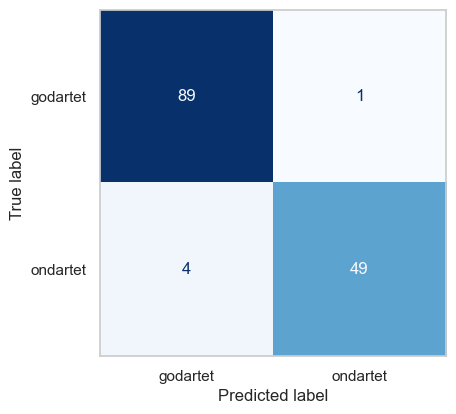

              precision    recall  f1-score   support

    godartet      0.957     0.989     0.973        90
    ondartet      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

pred = (p_test >= 0.5).astype(int)
print({k: round(v, 3) for k, v in klassifiserings_metrikker(y_test, pred).items()})

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["godartet", "ondartet"], cmap="Blues", colorbar=False)
plt.grid(False)
plt.show()

print(classification_report(y_test, pred, target_names=["godartet", "ondartet"], digits=3))

## Prediksjonsterskelen

Standard er 0,5, men terskelen er et valg som styrer avveiningen mellom falske positive og falske negative.
Dersom vi tenker at det er verre å overse en kreft enn å ta en ekstra prøve, senker vi terskelen.

In [ ]:
rader = []
for t in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    m = klassifiserings_metrikker(y_test, (p_test >= t).astype(int)); m["terskel"] = t; rader.append(m)
print(pd.DataFrame(rader).set_index("terskel").round(3))

         nøyaktighet  sensitivitet  spesifisitet  presisjon     F1
terskel                                                           
0.05           0.923         1.000         0.878      0.828  0.906
0.10           0.951         0.981         0.933      0.897  0.937
0.20           0.965         0.962         0.967      0.944  0.953
0.30           0.979         0.962         0.989      0.981  0.971
0.50           0.965         0.925         0.989      0.980  0.951
0.70           0.965         0.906         1.000      1.000  0.950
0.90           0.930         0.811         1.000      1.000  0.896


## Presisjon avhenger av prevalens

Sensitivitet og spesifisitet er egenskaper ved *testen*. Men presisjon (PPV) avhenger også av hvor vanlig sykdommen er :

$$ \text{PPV} = \frac{\text{sens}\cdot\text{prev}}{\text{sens}\cdot\text{prev} + (1-\text{spes})(1-\text{prev})} $$

Datasettet har ca. 37 % ondartede kreftsvulster. Hva om modellen brukes i en populasjon der bare 1 % har sykdommen?

In [ ]:
m = klassifiserings_metrikker(y_test, (p_test >= 0.5).astype(int))
sens, spes = m["sensitivitet"], m["spesifisitet"]
for prev in [0.37, 0.10, 0.01]:
    ppv = sens * prev / (sens * prev + (1 - spes) * (1 - prev))
    print(f"Prevalens {prev:5.0%}:  sens = {sens:.3f}, spes = {spes:.3f}  ->  presisjon (PPV) = {ppv:.2f}")

Prevalens   37%:  sens = 0.925, spes = 0.989  ->  presisjon (PPV) = 0.98
Prevalens   10%:  sens = 0.925, spes = 0.989  ->  presisjon (PPV) = 0.90
Prevalens    1%:  sens = 0.925, spes = 0.989  ->  presisjon (PPV) = 0.46


> Samme modell, men når prevalensen faller blir de fleste positive prediksjoner falske alarmer. 

